# Setup

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

# Task 1

## 1.1

In [105]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [107]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Task 1.1

First of all, we show you the difference in mean of five features beteween no purchase and purchase(by using label data).

In [108]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

story_table = (
    df.groupby("Revenue")[story_features]
      .mean()
      .T
)

story_table.columns = ["No purchase", "Purchase"]

story_table

,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555


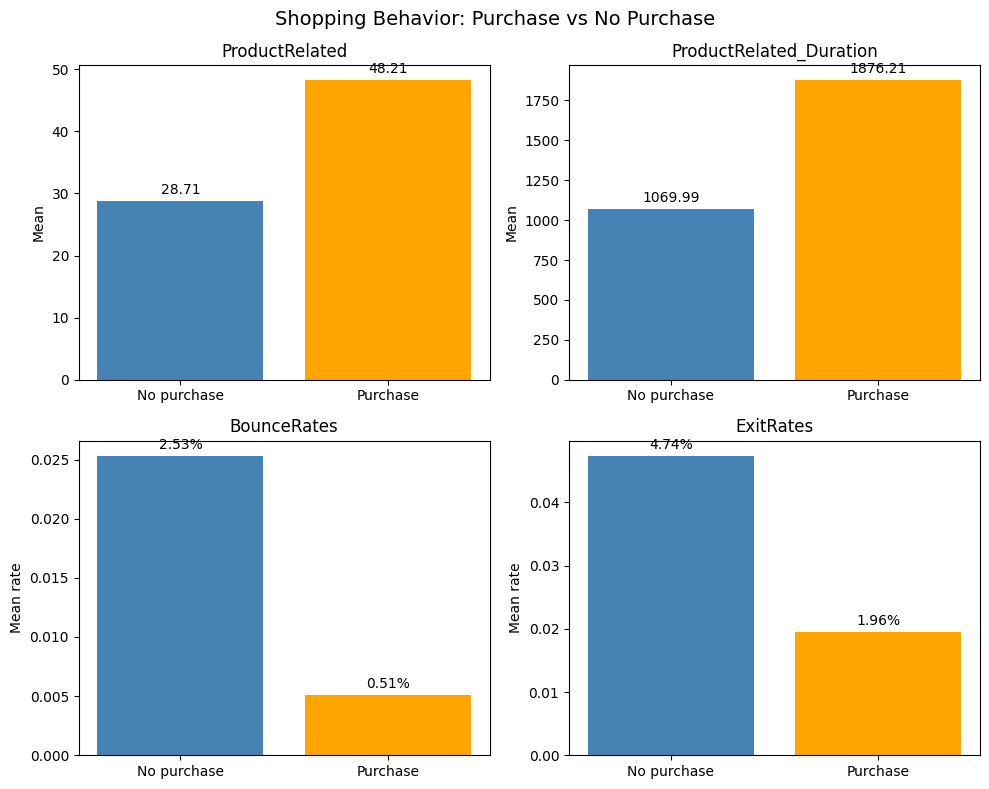

In [109]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
]

story_table = (
    df.groupby("Revenue")[story_features]
      .mean()
      .T
)

story_table.columns = ["No purchase", "Purchase"]

display(story_table)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for ax, feature in zip(axes, story_features):

    values = story_table.loc[feature]

    bars = ax.bar(
        ["No purchase", "Purchase"],
        values,
        color=["steelblue", "orange"]
    )

    # BounceRate and ExitRate are easier to understand as percentages
    if feature in ["BounceRates", "ExitRates"]:

        labels = [
            f"{value * 100:.2f}%"
            for value in values
        ]

        ax.set_ylabel("Mean rate")

    else:

        labels = [
            f"{value:.2f}"
            for value in values
        ]

        ax.set_ylabel("Mean")

    ax.bar_label(
        bars,
        labels=labels,
        padding=3
    )

    ax.set_title(feature)


fig.suptitle(
    "Shopping Behavior: Purchase vs No Purchase",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Dataset first exploration

We compared sessions that resulted in a purchase with sessions that did not.  
The clearest difference is that purchasing sessions show much stronger engagement with product pages. On average, they viewed about 48 product-related pages, compared to about 29 pages for non-purchasing sessions. They also spent much more time on these pages: around 1,876 seconds, compared to 1,070 seconds.  
At the same time, purchasing sessions had much lower bounce and exit rates. The average bounce rate decreased from about 2.53% to 0.51%, while the exit rate decreased from 4.74% to 1.96%.  
Overall, the data suggests that sessions resulting in purchases are characterized by more product exploration, longer browsing time, and lower bounce and exit rates.

## 1.2

In [110]:
df["BrowserGroup"] = np.where(
    df["Browser"] == 13,
    "Browser 13",
    "Other browsers"
)

print(df["BrowserGroup"].value_counts())

BrowserGroup
Other browsers    12269
Browser 13           61
Name: count, dtype: int64


In [111]:
story_table = (
    df.groupby("BrowserGroup")
      .mean(numeric_only=True)
      .T
)

story_table.columns = ["Other Browsers", "Browser 13"]

story_table

,Other Browsers,Browser 13
Administrative,1.754098,2.317956
Administrative_Duration,73.716530,80.853921
Informational,0.229508,0.504931
Informational_Duration,4.717486,34.620336
ProductRelated,14.885246,31.815225
ProductRelated_Duration,699.388395,1197.209080
BounceRates,0.034373,0.022131
ExitRates,0.052842,0.043024
PageValues,26.268249,5.787936
SpecialDay,0.000000,0.061733


,Other Browsers,Browser 13,Difference (%)
Informational_Duration,34.620336,4.717486,-86.373655
Informational,0.504931,0.229508,-54.546633
ProductRelated,31.815225,14.885246,-53.213451
ProductRelated_Duration,1197.209080,699.388395,-41.581767
Administrative,2.317956,1.754098,-24.325635
Administrative_Duration,80.853921,73.716530,-8.827514
ExitRates,0.043024,0.052842,22.820300
BounceRates,0.022131,0.034373,55.316528


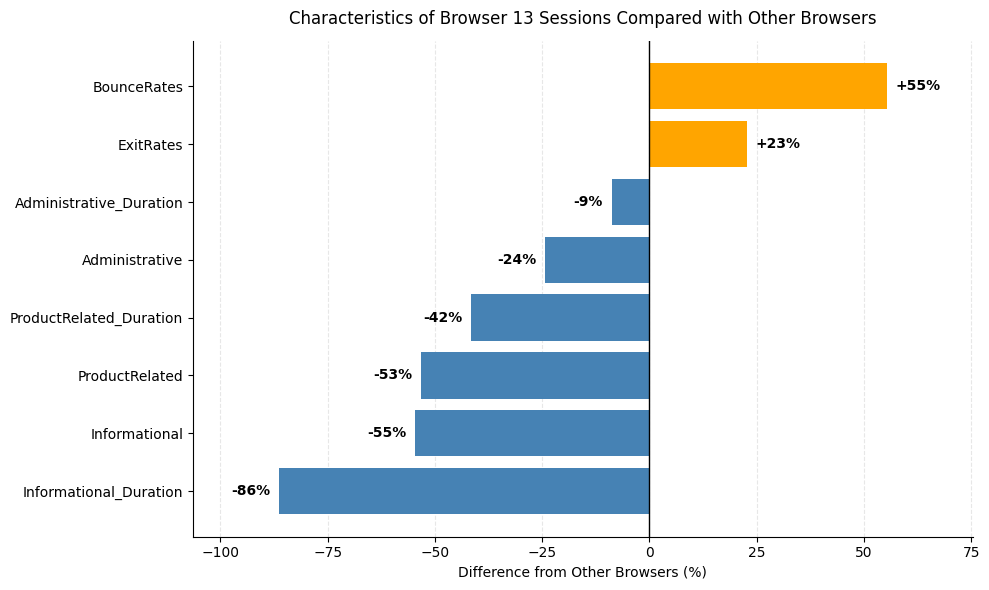

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
]

browser13 = df[df["Browser"] == 13]
others = df[df["Browser"] != 13]

comparison_table = pd.DataFrame({
    "Other Browsers": others[features].mean(),
    "Browser 13": browser13[features].mean()
})

# Percentage difference compared with other browsers
comparison_table["Difference (%)"] = (
    (comparison_table["Browser 13"]
     - comparison_table["Other Browsers"])
    / comparison_table["Other Browsers"]
) * 100

# Sort for easier interpretation
comparison_table = comparison_table.sort_values("Difference (%)")

display(comparison_table)


# -------------------------
# Visualization
# -------------------------

fig, ax = plt.subplots(figsize=(10, 6))

differences = comparison_table["Difference (%)"]

# Different colors:
# negative = Browser 13 lower
# positive = Browser 13 higher
colors = [
    "steelblue" if value < 0 else "orange"
    for value in differences
]

bars = ax.barh(
    comparison_table.index,
    differences,
    color=colors
)

# Zero reference line
ax.axvline(
    0,
    color="black",
    linewidth=1
)

# Percentage labels
for bar, value in zip(bars, differences):

    y = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 2,
            y,
            f"+{value:.0f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

    else:
        ax.text(
            value - 2,
            y,
            f"{value:.0f}%",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )


# Give labels enough room
xmin = differences.min() - 20
xmax = differences.max() + 20

ax.set_xlim(xmin, xmax)

ax.set_xlabel("Difference from Other Browsers (%)")

ax.set_title(
    "Characteristics of Browser 13 Sessions Compared with Other Browsers",
    pad=12
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid for readability
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

This chart compares the average characteristics of Browser 13 sessions with those of all other browser sessions. Each bar shows the percentage difference between the Browser 13 mean and the mean for other browsers. Positive values mean Browser 13 is higher, while negative values mean Browser 13 is lower.

### observation
Browser 13 sessions show much lower browsing engagement than sessions using other browsers. They visit fewer administrative pages (-24%), informational pages (-55%), and product-related pages (-53%). They also spend less time on these page types, especially on informational pages, where the average duration is about 86% lower. Product-related duration is also about 42% lower. At the same time, Browser 13 sessions have a 55% higher bounce rate and a 23% higher exit rate. Overall, this suggests that Browser 13 sessions tend to be shorter and involve less interaction with the website.

## Task 2: Normalization
According to the documentation, before the clustering analysis, the data frame needs to be preprocessed. Numerical variables will be standardized using StandardScaler, while nominal variables will be one-hot encoded. Boolean variables will be turned into 0/1 values.

* Applying the log trasformation to strongly right-skewed numerical features
* Applying the StandardScaler to numerical variables
* one-hot encoding for the nominal variables
* Boolean variables will be turned into 0/1 values

In [113]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("online_shoppers_intention.csv")

# Separate the class label
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"]).copy()

# Convert binary variable
X["Weekend"] = X["Weekend"].astype(int)

# Define numerical features
numerical_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

# Strongly right-skewed numerical features
log_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues"
]

# Nominal categorical features
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

# Reduce skewness of strongly skewed numerical features
X[log_columns] = np.log1p(
    X[log_columns]
)

# Scale numerical features only
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(
    X[numerical_columns]
)

# One-hot encode nominal features
# These remain 0/1 and are NOT standardized
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    dtype=int
)

# Keep the variable name used in the later tasks
X_scaled_cleaned = X.to_numpy(dtype=float)

# Make df.columns correspond to the preprocessed matrix
# so your later code works:
# pd.DataFrame(X_scaled_cleaned, columns=df.columns)
df = X.copy()

print("Original number of rows:", X.shape[0])
print("Number of features after preprocessing:", X.shape[1])

display(X.head())

Original number of rows: 12330
Number of features after preprocessing: 74


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.923678,-0.975402,-0.478085,-0.464858,-1.950729,-2.918505,3.667189,3.229316,-0.492303,-0.308821,...,0,0,0,0,0,0,0,0,0,1
1,-0.923678,-0.975402,-0.478085,-0.464858,-1.589955,-0.875249,-0.457683,1.171473,-0.492303,-0.308821,...,0,0,0,0,0,0,0,0,0,1
2,-0.923678,-0.975402,-0.478085,-0.464858,-1.950729,-2.918505,3.667189,3.229316,-0.492303,-0.308821,...,0,0,0,0,0,0,0,0,0,1
3,-0.923678,-0.975402,-0.478085,-0.464858,-1.589955,-2.282539,0.573535,1.994610,-0.492303,-0.308821,...,0,0,0,0,0,0,0,0,0,1
4,-0.923678,-0.975402,-0.478085,-0.464858,-0.433884,0.235343,-0.045196,0.142551,-0.492303,-0.308821,...,0,0,0,0,0,0,0,0,0,1


## Affinity Propagation, DBSCAN and BIRCH clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AffinityPropagation, DBSCAN, Birch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


# Prepare data
df_scaled_cleaned = pd.DataFrame(
    X_scaled_cleaned,
    columns=df.columns
)

# Same sample is used for ALL clustering methods
SAMPLE_SIZE = len(df_scaled_cleaned)
RANDOM_STATE = 42

df_sample = df_scaled_cleaned.sample(
    n=min(SAMPLE_SIZE, len(df_scaled_cleaned)),
    random_state=RANDOM_STATE
)

# Full-dimensional data used for clustering
X_cluster = df_sample.to_numpy()

print("Sample size:", X_cluster.shape[0])
print("Number of features:", X_cluster.shape[1])

Sample size: 12330
Number of features: 74


### 3.1 Affinity Propagation Clustering
It measures similarity between observations and iteratively selects some actual observations as exemplars. Other observations are assigned to those representatives. The preference parameter strongly affects how many exemplars, and therefore how many clusters, are created.

In [115]:
AP_PREFERENCE = -3000

affinity_model = AffinityPropagation(
    damping=0.9,
    preference=AP_PREFERENCE,
    max_iter=300,
    convergence_iter=15,
    random_state=RANDOM_STATE
)

labels_ap = affinity_model.fit_predict(
    X_cluster
)

n_clusters_ap = len(
    np.unique(labels_ap)
)

print("Affinity Propagation")
print("Preference:", AP_PREFERENCE)
print("Number of clusters:", n_clusters_ap)

print(
    pd.Series(labels_ap)
      .value_counts()
      .sort_index()
)

Affinity Propagation
Preference: -3000
Number of clusters: 10
0    1798
1     937
2    1048
3     761
4     891
5     718
6    2893
7    1246
8     714
9    1324
Name: count, dtype: int64


### 3.2 DBSCAN Clustering

In [116]:
MIN_SAMPLES = 5

# Find distance to the 5th nearest neighbour
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES
)

neighbors.fit(
    X_cluster
)

distances, _ = neighbors.kneighbors(
    X_cluster
)

k_distances = np.sort(
    distances[:, -1]
)

DBSCAN_EPS = 2.25

dbscan_model = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=MIN_SAMPLES
)

labels_dbscan = dbscan_model.fit_predict(
    X_cluster
)

n_clusters_dbscan = len(
    set(labels_dbscan) - {-1}
)

n_noise = np.sum(
    labels_dbscan == -1
)

print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

print(
    pd.Series(labels_dbscan)
      .value_counts()
      .sort_index()
)

Number of clusters: 3
Number of noise points: 924
-1      924
 0    11390
 1       14
 2        2
Name: count, dtype: int64


#### result
About 92% of the sessions belong to one large dense region. About 7.5% are noise, and only a tiny number form additional groups.
That means I would not describe this as three meaningful clusters. Technically there are three cluster labels, but practically the result is dominated by one main cluster.

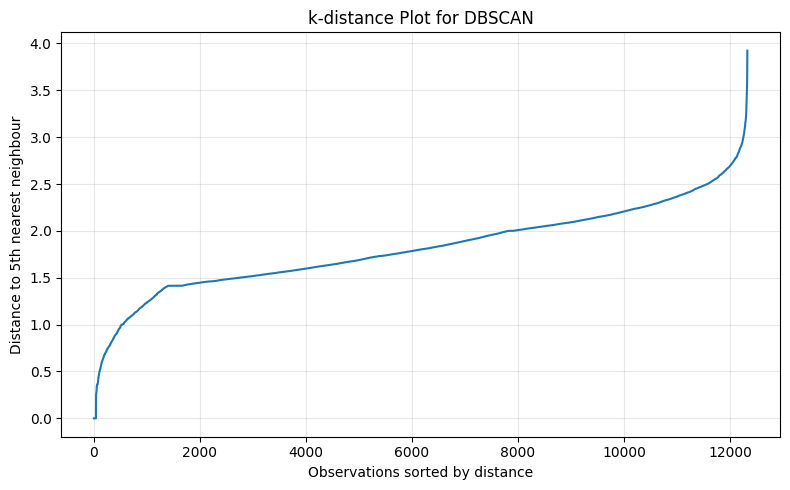

In [118]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_distances
)

plt.xlabel("Observations sorted by distance")

plt.ylabel(
    f"Distance to {MIN_SAMPLES}th nearest neighbour"
)

plt.title("k-distance Plot for DBSCAN")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### How to choose the `eps` parameter
This graph shows how many observations would be classified as core points for a given eps, with min_samples fixed. A core point is an observation whose eps-neighborhood contains at least min_samples observations, meaning that it lies in a sufficiently dense region.

I chose eps near the elbow because the elbow approximately marks the transition from relatively dense regions to much sparser regions in the data.(`eps`=1.5~2.5 is the sweet spot)

In [ ]:
eps_values = [
    1.5,
    2.0,
    2.25,
    2.5,
    2.75,
    3.0
]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=MIN_SAMPLES
    )

    labels = model.fit_predict(
        X_cluster
    )

    n_clusters = len(
        set(labels) - {-1}
    )

    noise_ratio = np.mean(
        labels == -1
    )

    print(
        f"eps={eps:.2f} | "
        f"clusters={n_clusters} | "
        f"noise={noise_ratio * 100:.1f}%"
    )

### 3.3 BIRCH Clustering

In [120]:
BIRCH_N_CLUSTERS = 7

birch_model = Birch(
    n_clusters=BIRCH_N_CLUSTERS
)

labels_birch = birch_model.fit_predict(
    X_cluster
)

n_clusters_birch = len(
    np.unique(labels_birch)
)

print("Birch")
print("Number of clusters:", n_clusters_birch)

print(
    pd.Series(labels_birch)
      .value_counts()
      .sort_index()
)

Birch
Number of clusters: 7
0    3868
1    1477
2     802
3    1319
4     933
5    2980
6     951
Name: count, dtype: int64


### visualization
PCA is used only for visualization. The first two principal components explain about 44% of the variance, so the two-dimensional plots do not show all of the cluster structure used by the algorithms.

In [121]:
# PCA — visualization
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_cluster
)

pc1_ratio = (
    pca.explained_variance_ratio_[0]
    * 100
)

pc2_ratio = (
    pca.explained_variance_ratio_[1]
    * 100
)

print(f"PC1: {pc1_ratio:.2f}%")
print(f"PC2: {pc2_ratio:.2f}%")

print(
    f"PC1 + PC2: "
    f"{pc1_ratio + pc2_ratio:.2f}%"
)

PC1: 31.55%
PC2: 12.39%
PC1 + PC2: 43.94%


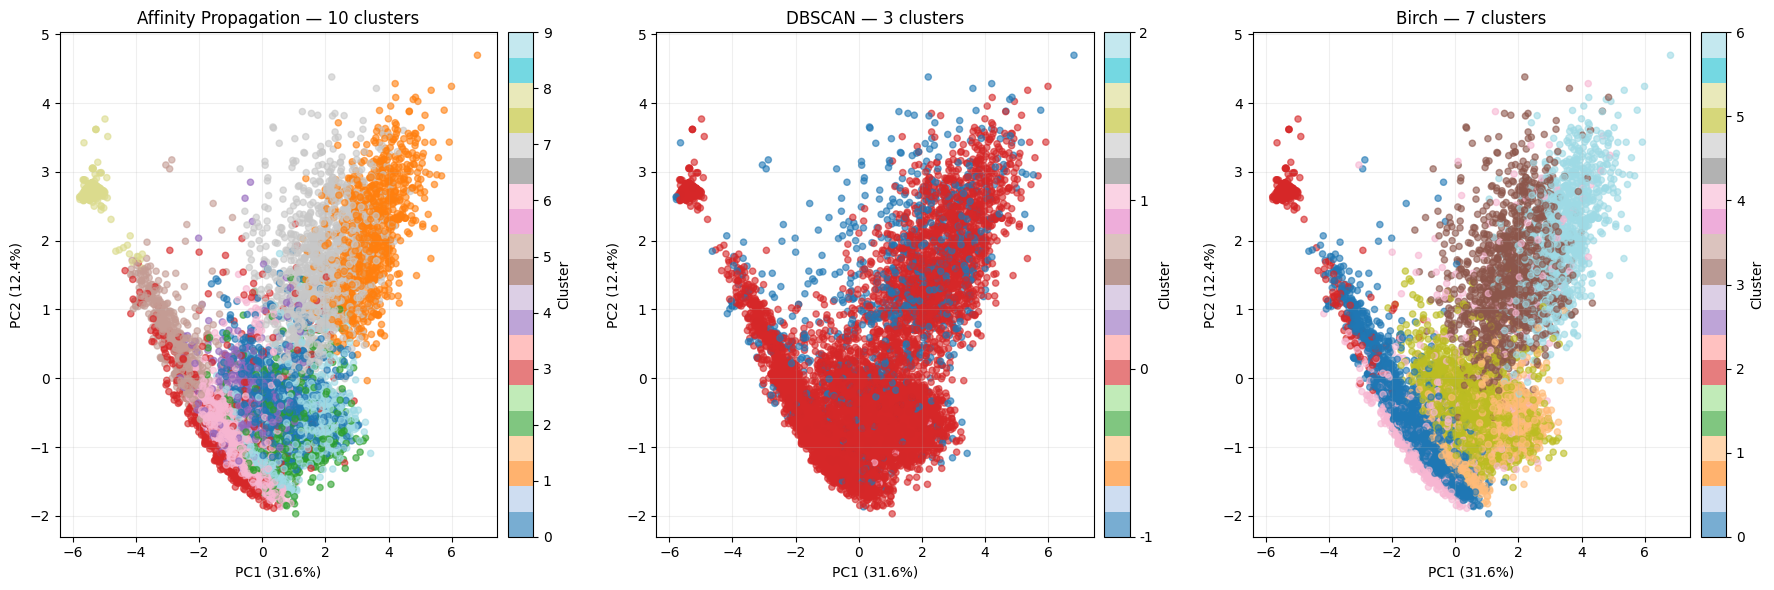

In [122]:
results = [
    (
        "Affinity Propagation",
        labels_ap
    ),
    (
        "DBSCAN",
        labels_dbscan
    ),
    (
        "Birch",
        labels_birch
    )
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)


for ax, (name, labels) in zip(
    axes,
    results
):

    unique_labels = sorted(
        np.unique(labels)
    )

    n_clusters = len(
        set(labels) - {-1}
    )

    # Convert cluster IDs to consecutive integers
    # for visualization
    label_map = {
        label: i
        for i, label in enumerate(unique_labels)
    }

    plot_labels = np.array([
        label_map[label]
        for label in labels
    ])

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=plot_labels,
        cmap="tab20",
        s=20,
        alpha=0.6
    )

    ax.set_xlabel(
        f"PC1 ({pc1_ratio:.1f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pc2_ratio:.1f}%)"
    )

    ax.set_title(
        f"{name} — {n_clusters} clusters"
    )

    ax.grid(
        alpha=0.2
    )

    # Avoid unreadable colorbars when there
    # are too many clusters
    if len(unique_labels) <= 15:

        colorbar = fig.colorbar(
            scatter,
            ax=ax,
            ticks=range(len(unique_labels)),
            pad=0.02
        )

        colorbar.set_label(
            "Cluster"
        )

        colorbar.set_ticklabels(
            unique_labels
        )


plt.tight_layout()
plt.show()

### observation
The clustering was performed in the full preprocessed feature space, while PCA was used only for visualization. PC1 and PC2 explain about 31.6% and 12.4% of the variance respectively, so the figure displays about 44% of the total variance.

### comparison

| Method | Main idea | Need number of clusters beforehand? | Can detect noise? | Important parameter | Your current result |
|---|---|---|---|---|---|
| Affinity Propagation | Chooses representative points called **exemplars** and groups similar points around them | No | No | `preference` | 10 clusters |
| DBSCAN | Finds clusters as **dense regions** of points | No | Yes (`-1` = noise) | `eps`, `min_samples` | 3 clusters + noise |
| Birch | Builds compact **hierarchical summaries/subclusters**, then forms final clusters | Usually yes in your setup | No | `n_clusters` | 7 clusters |

## 4.1: Silhouette Score

### what is the Silhouette Score?
Measure of clustering quality for k-cluster methods independent of $k$.

For one observation $o$:

Let $a(o)$ be average distance from $o$ to points in its own cluster,
$$ 
\begin{aligned}
a(o)&=\frac{\sum_{o'\in C_i,o\neq o'}dist(o,o')}{|C_j|-1} \quad (o \in C_i(1\leq i \leq k))
\end{aligned} 
$$
and
let $b(o)$ be smallest average distance from $o$ to any other cluster
$$
\begin{aligned}
b(o)=min_{C_j:1\leq j \leq k, i\neq j}\frac{\sum_{o'\in C_j}dist(o,o')}{|C_j|}

\end{aligned}
$$
Then let $C_I$ be the cluster to which the data point $o$ belongs,
$$
\begin{aligned}
s(o)=
\begin{cases}
\frac{b(o)-a(o)}
{\max(a(o),b(o))} & (|C_I|>1)\\
0 & (|C_I|=1)
\end{cases}
\end{aligned}
$$

The final Silhouette score is the average of $s(o)$ over all observations.

Interpretation:
- $s_C > 0.7$: strong cluster structure
- $s_C > 0.5$: reasonable cluster structure
- $s_C > 0.25$: weak cluster structure
- $s_C < 0.25$: no cluster structure

The higher the value $s_C$ is, the better the clustering is.


In [ ]:
import math
import numpy as np


def euclidean_distance(point1, point2):
    """
    Manually calculate Euclidean distance.
    """
    total = 0.0

    for x, y in zip(point1, point2):
        total += (x - y) ** 2

    return math.sqrt(total)


def manual_silhouette_score(X, labels)->float:
    """
    Manually calculate the mean Silhouette score.

    Noise points with label -1 are excluded.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Remove DBSCAN noise
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    unique_clusters = np.unique(labels_eval)

    if len(unique_clusters) < 2:
        return 0.0

    silhouette_values = []

    for i in range(len(X_eval)):

        current_cluster = labels_eval[i]

        # a(i): same-cluster distance
        same_cluster_indices = [
            j
            for j in range(len(X_eval))
            if labels_eval[j] == current_cluster
            and j != i
        ]

        # A cluster containing only one point
        if len(same_cluster_indices) == 0:
            silhouette_values.append(0.0)
            continue

        a_i = 0.0

        for j in same_cluster_indices:
            a_i += euclidean_distance(
                X_eval[i],
                X_eval[j]
            )

        a_i /= len(same_cluster_indices)

        # b(i): nearest other cluster
        b_i = float("inf")

        for cluster in unique_clusters:
            if cluster == current_cluster:
                continue
            other_cluster_indices = [
                j
                for j in range(len(X_eval))
                if labels_eval[j] == cluster
            ]
            average_distance = 0.0
            for j in other_cluster_indices:
                average_distance += euclidean_distance(
                    X_eval[i],
                    X_eval[j]
                )
            average_distance /= len(
                other_cluster_indices
            )
            if average_distance < b_i:
                b_i = average_distance
        # Silhouette for point i
        denominator = max(
            a_i,
            b_i
        )
        if denominator == 0:
            s_i = 0.0
        else:
            s_i = (
                b_i - a_i
            ) / denominator
        silhouette_values.append(
            s_i
        )

    return sum(silhouette_values) / len(
        silhouette_values
    )

In [125]:
silhouette_ap = manual_silhouette_score(
    X_cluster,
    labels_ap
)
print(
    "Affinity Propagation:",
    silhouette_ap
)

Affinity Propagation: 0.11698858062800488


In [126]:
silhouette_dbscan = manual_silhouette_score(
    X_cluster,
    labels_dbscan
)
print(
    "DBSCAN:",
    silhouette_dbscan
)

DBSCAN: 0.013304846890869644


In [127]:
silhouette_birch = manual_silhouette_score(
    X_cluster,
    labels_birch
)
print(
    "Birch:",
    silhouette_birch
)

KeyboardInterrupt: 

### Task 4.2 Davies Bouldin Score 
Lower is better.
### Interpretation:
smaller Davies–Bouldin → clusters are more compact and better separated.

In [ ]:
from sklearn.metrics import davies_bouldin_score


def evaluate_davies_bouldin(
    X,
    labels
):

    X = np.asarray(X)
    labels = np.asarray(labels)

    # Exclude DBSCAN noise
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(np.unique(labels_eval)) < 2:
        return np.nan

    return davies_bouldin_score(
        X_eval,
        labels_eval
    )


db_ap = evaluate_davies_bouldin(
    X_cluster,
    labels_ap
)

db_dbscan = evaluate_davies_bouldin(
    X_cluster,
    labels_dbscan
)

db_birch = evaluate_davies_bouldin(
    X_cluster,
    labels_birch
)


print("Affinity Propagation:", db_ap)
print("DBSCAN:", db_dbscan)
print("Birch:", db_birch)

### Task 4.3 Calinski-Harabasz Index 
Higher is better.


In [ ]:
from sklearn.metrics import calinski_harabasz_score


def evaluate_calinski_harabasz(
    X,
    labels
):

    X = np.asarray(X)
    labels = np.asarray(labels)

    # Exclude DBSCAN noise
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(np.unique(labels_eval)) < 2:
        return np.nan

    return calinski_harabasz_score(
        X_eval,
        labels_eval
    )


ch_ap = evaluate_calinski_harabasz(
    X_cluster,
    labels_ap
)

ch_dbscan = evaluate_calinski_harabasz(
    X_cluster,
    labels_dbscan
)

ch_birch = evaluate_calinski_harabasz(
    X_cluster,
    labels_birch
)


print("Affinity Propagation:", ch_ap)
print("DBSCAN:", ch_dbscan)
print("Birch:", ch_birch)

In [ ]:
results_task4 = pd.DataFrame({
    "Silhouette ↑": [
        silhouette_ap,
        silhouette_dbscan,
        silhouette_birch
    ],

    "Davies-Bouldin ↓": [
        db_ap,
        db_dbscan,
        db_birch
    ],

    "Calinski-Harabasz ↑": [
        ch_ap,
        ch_dbscan,
        ch_birch
    ]
},
index=[
    "Affinity Propagation",
    "DBSCAN",
    "Birch"
])

display(
    results_task4.round(3)
)

# Task 5

## 5.1: Euclidean distance + DBSCAN

The Euclidean distance function was manually implemented in task 4.1.  
Since the function does not use any predefined distance functions or libraries, we reuse the same implementation here as the distance metric for DBSCAN.

In [ ]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=15,
    metric=euclidean_distance
)

labels_euclidean = dbscan.fit_predict(
    X_pca
)

unique_labels = np.unique(
    labels_euclidean
)

# Plot
fig, ax = plt.subplots(
    figsize=(8, 6)
)

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_pca[:, 0],       # PC1
    X_pca[:, 3],       # PC4
    c=labels_euclidean,
    cmap=cmap,
    alpha=0.7,
    s=35
)

# Only show a limited number of colourbar labels
colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label(
    "Cluster"
)

# Axis labels
ax.set_xlabel(
    f"PC1 ({pca_cluster.explained_variance_ratio_[0] * 100:.1f}%)"
)

ax.set_ylabel(
    f"PC4 ({pca_cluster.explained_variance_ratio_[3] * 100:.1f}%)"
)

ax.set_title(
    "DBSCAN Clustering — PC1 vs PC4"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


## 5.2: Manhattan distance + DBSCAN

In [ ]:
def manhattan_distance(point1, point2):
    assert(len(point1) == len(point2))
    distance = 0
    for x1, x2 in zip(point1, point2):
        distance += abs(x1 - x2)
    return distance

dbscan = DBSCAN(
    eps=1.65,
    min_samples=12,
    metric=manhattan_distance
)

labels_manhattan = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels_manhattan)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 3],
    c=labels_manhattan,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title(
    "DBSCAN Clustering — PC1 vs PC4"
)

plt.show()


## 5.3: Cosine similarity distance + DBSCAN

In [ ]:
def cosine_distance(point1, point2):
    dot_product = 0
    magnitude1 = 0
    magnitude2 = 0

    for x1, x2 in zip(point1, point2):
        dot_product += x1 * x2
        magnitude1 += x1 * x1
        magnitude2 += x2 * x2

    magnitude1 = math.sqrt(magnitude1)
    magnitude2 = math.sqrt(magnitude2)

    if magnitude1 == 0 or magnitude2 == 0:
        return 0

    cosine_similarity = dot_product / (magnitude1 * magnitude2)

    return 1 - cosine_similarity

dbscan = DBSCAN(
    eps=0.03,
    min_samples=15,
    metric=cosine_distance)

labels_cosine = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels_cosine)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 3],
    c=labels_cosine,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title(
    "DBSCAN Clustering — PC1 vs PC4"
)

plt.show()

## 5.4: Evaluate different distance functions

In [ ]:
# Calculate silhouette values for each distance function
from numpy import iterable


score_euclidean = calculate_silhouette(labels_euclidean)
score_manhattan = calculate_silhouette(labels_manhattan)
score_cosine = calculate_silhouette(labels_cosine)

def flatten_list(l):
    flatened_l = []
    for val in l:
        if iterable(val):
            flatened_l.extend(val)
        else:
            flatened_l.append(val)
    return flatened_l

# Flatten the results (remove nested lists)
flat_euclidean = flatten_list(score_euclidean)
flat_manhattan = flatten_list(score_manhattan)
flat_cosine = flatten_list(score_cosine)


# Calculate the average silhouette score
average_euclidean = sum(flat_euclidean) / len(flat_euclidean)
average_manhattan = sum(flat_manhattan) / len(flat_manhattan)
average_cosine = sum(flat_cosine) / len(flat_cosine)


# Print the results
print("Euclidean silhouette score:", average_euclidean)
print("Manhattan silhouette score:", average_manhattan)
print("Cosine silhouette score:", average_cosine)

#Interpretation:
# s > 0.7: strong cluster structure
# s > 0.5: reasonable cluster structure
# s > 0.25: weak cluster structure
# s < 0.25: no cluster structure

### Visualisation of the different silhouette scores

In [ ]:
distance_functions = ["Euclidean", "Manhattan", "Cosine"]
silhouette_scores = [
    average_euclidean,
    average_manhattan,
    average_cosine
    ]

plt.bar(distance_functions, silhouette_scores)

plt.xlabel("Distance function")
plt.ylabel("Silhouette score")
plt.title("Effect of Distance Function on DBSCAN")

plt.show()